In [82]:
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn.functional import pad
import matplotlib.pyplot as plt

Bild saknas: images\2019-03_1.jpg
Bild saknas: images\2019-03_2.jpg
Bild saknas: images\2019-03_3.jpg
Bild saknas: images\2020-106_1.jpg
Bild saknas: images\2020-106_2.jpg
Bild saknas: images\2020-106_3.jpg
Bild saknas: images\2020-115_1.jpg
Bild saknas: images\2020-115_2.jpg
Bild saknas: images\2020-115_3.jpg
Bild saknas: images\b2024-06223 (2)_1.jpg
Bild saknas: images\b2024-06223 (2)_2.jpg
Bild saknas: images\b2024-06223 (2)_3.jpg


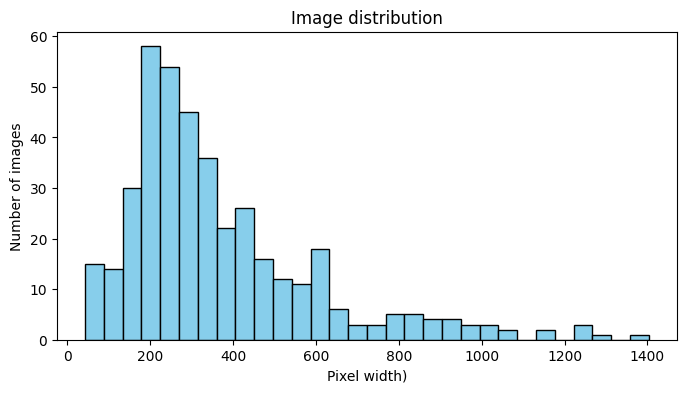

In [88]:
import matplotlib.pyplot as plt
from PIL import Image

#Dataset
dataset = MyDataset("labels.csv", "images")

#Collect all widths 
widths = []
for path, _ in dataset.samples:
    with Image.open(path) as im:
        w, h = im.size
        widths.append(w)

#Histogram
plt.figure(figsize=(8, 4))
plt.hist(widths, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Pixel width)")
plt.ylabel("Number of images")
plt.title("Image distribution")
plt.show()


In [89]:
class Dataset(Dataset):
    def __init__(self, file_path, img_dir, transform=None):
        df = pd.read_csv(file_path)

        self.img_dir = Path(img_dir)
        self.transform = transforms.ToTensor() if transform is None else transform

        self.samples = []
        for _, row in df.iterrows():
            name = str(row.iloc[0]).strip()
            label = row.iloc[1]
            path = self.img_dir / name

            if path.exists():
                self.samples.append((path, label))

        #Target size
        self.target_w = 400
        self.target_h = 200
        print(f"Image width {self.target_w} and height {self.target_h}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")
        w, h = img.size
        new_h = self.target_h
        new_w = int(w * (new_h / h))  
        img = img.resize((new_w, new_h))

        img = self.transform(img) 
        _, h, w = img.shape

        #If width is greater than target 
        if w > self.target_w:
            #Crop in center
            start = (w - self.target_w) // 2
            end = start + self.target_w
            img = img[:, :, start:end]

        #If width is less than target
        elif w < self.target_w:
            #Pad in centrer
            pad_w = self.target_w - w
            pad_left = pad_w // 2
            pad_right = pad_w - pad_left
            img = pad(img, (pad_left, pad_right, 0, 0), value=0)

        return img, label, path.name

In [90]:
#Dataset and dataloader
dataset = Dataset("labels.csv", "images")
loader = DataLoader(dataset, batch_size=8, shuffle=True)

#Batch
imgs, labels, names = next(iter(loader))
print("Batch:", imgs.shape)

Image width 400 and height 200
Batch: torch.Size([8, 3, 200, 400])


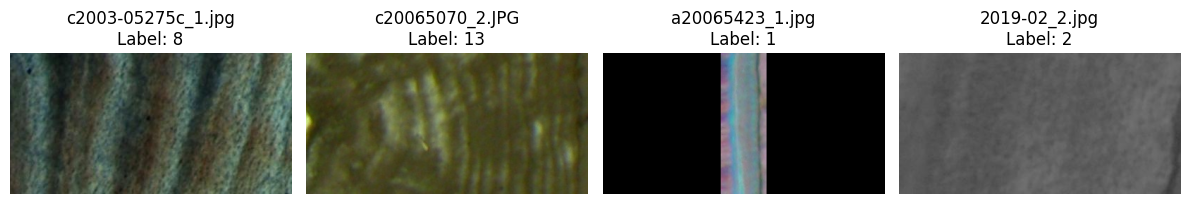

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    img = imgs[i].permute(1, 2, 0).numpy()  
    axes[i].imshow(img)
    axes[i].set_title(f"{names[i]}\nLabel: {labels[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()